In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import os

# Look one folder up, then into the models folder
model_path = "../models/vision_model.keras"
model = tf.keras.models.load_model(model_path)

# Scan an image
def test_screenshot(image_path):
    if not os.path.exists(image_path):
        return "File not found! Please check the file path."
    
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array, verbose=0)
    score = prediction[0][0]
    
    print(f"Image Scanned: {image_path}")
    if score > 0.5:
        print(f"Final Verdict: 🚨 PHISHING")
        print(f"Phishing Probability: {score*100:.2f}%")
    else:
        print(f"Final Verdict: ✅ SAFE")
        print(f"Safe Probability: {(1-score)*100:.2f}%")

test_image_path = "../data/images/phishing/cleaned_phishing_0.png"
test_screenshot(test_image_path)

Image Scanned: ../screenshots/screenshot.png
Final Verdict: 🚨 PHISHING
Phishing Probability: 70.26%


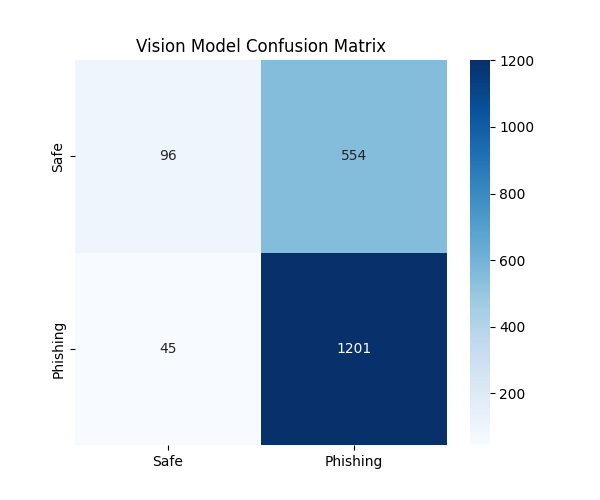

In [1]:
from IPython.display import Image, display
display(Image(filename='../results_nlp/vision_confusion_matrix.png'))